(tutorials:pauli_multislice)=
# Non-collinear magnetic scattering: the paraxial Pauli multislice

Ordinary multislice simulations, and the potentials that drive them, only capture the electrostatic phase shift imparted by the sample's Coulomb potential. A magnetic sample additionally deflects and rotates the electron's spin and orbital angular momentum through the Lorentz force and the Zeeman interaction, an effect that is invisible to a scalar (single-component) wave function no matter how the potential is built. Capturing it requires promoting the wave function to a genuinely two-component (spinor) object and evolving it with a magnetic generalization of the multislice equation.

*ab*TEM already has some support for this: for a *collinear* magnetization (all magnetic moments pointing along a single axis), the $A_z$ component of the magnetic vector potential can be folded directly into an effective electrostatic-like phase, and an ordinary scalar `multislice` simulation is enough. This tutorial covers the more general case: a full two-component **paraxial Pauli multislice** that also handles the in-plane vector potential $A_{xy}$ and the spin-dependent Zeeman term, and therefore works for *non-collinear* or canted magnetic textures as well as collinear ones.

The method implemented here follows Edström, Lubk and Rusz {cite}`edstrom_pauli_prb,edstrom_pauli_prl`.


## The paraxial Pauli equation

The scalar multislice equation is generalized to a two-component spinor wave function $|\psi\rangle = (\psi_\uparrow, \psi_\downarrow)$ obeying a paraxial equation of motion in the beam direction $z$,

```{math}
:label: eq:pauli_multislice
\frac{d}{dz}|\psi\rangle = i H |\psi\rangle \, ,
\qquad
H = \underbrace{\frac{\lambda}{4\pi}\nabla_{xy}^2}_{\text{propagation}}
 \;+\; \underbrace{\frac{\sigma_e V}{\Delta z}}_{\text{electrostatic transmission}}
 \;-\; \underbrace{\frac{e}{\hbar} A_z}_{\text{collinear magnetic phase}}
 \;+\; \underbrace{i \frac{e}{\hbar k} \vec{A}_{xy}\!\cdot\!\nabla_{xy}}_{\text{orbital coupling}}
 \;-\; \underbrace{\frac{e}{2\hbar k}\vec{\sigma}\!\cdot\!\vec{B}}_{\text{spin Zeeman}} \, .
```

with $k = 2\pi/\lambda$ the relativistically corrected wave number and $\vec{\sigma} = (\sigma_x, \sigma_y, \sigma_z)$ the Pauli matrices. Reading off the terms:

- The first two terms are exactly the ordinary (non-magnetic) multislice propagation and transmission — see the [multislice walkthrough](walkthrough:multislice).
- The $A_z$ term is the collinear magnetic phase shift already available in *ab*TEM's collinear magnetism support: a spin-independent phase that can be absorbed into an effective potential when the magnetization has no in-plane or canted component.
- The orbital coupling term is a new spin-independent term proportional to $\vec{A}_{xy}\cdot\nabla_{xy}$, which deflects the transverse motion of the electron in a way that depends on its orbital angular momentum.
- The Zeeman term mixes the two spin components through $\sigma_x$ and $\sigma_y$ whenever the field has an in-plane component — this is precisely the non-collinear physics that a scalar treatment cannot represent, and the reason a spinor wave function is required.

All four magnetic coefficients above are mass-independent: the relativistic $\gamma$-factor that enters $k$ and $\lambda$ cancels against the $(\hbar k)^{-1}$ prefactors, so relativistic correctness follows entirely from using the correct (relativistic) wavelength.


## API overview

Two pieces of new API are used below:

- `Waves.to_spinor(polarization)` turns an ordinary scalar `Waves` object into a two-component spinor by adding a leading, labeled `SpinAxis` ensemble axis of length 2 holding the spin-up and spin-down amplitudes `polarization[0] * psi`, `polarization[1] * psi`. Apart from the Pauli step itself, the spin axis behaves like any other ensemble axis: it appears in detector output, gets summed over for spin-averaged signals, or can be differenced for spin-contrast.
- `abtem.magnetism.multislice.pauli_multislice(waves, potential, vector_potential=..., magnetic_field=..., average_field=..., algorithm=...)` runs the Pauli multislice through an electrostatic `potential` together with a magnetic vector potential and/or magnetic field. Two evolution schemes are available through the same `algorithm` objects used by ordinary `multislice`: `RealSpaceMultislice` (the default; an exact per-slice Taylor expansion) and `FourierMultislice` (a Strang-split operator-splitting scheme that is 5-15x faster and the recommended choice for anything beyond a toy example — see the closing note below).

Magnetic fields are supplied to `pauli_multislice` in one of two complementary ways:

- A **periodic** field, built as a `VectorPotentialArray`/`MagneticFieldArray` (e.g. from atomic magnetic moments via `abtem.magnetism.iam`, or from a magnetization density via the DFT-agnostic `abtem.magnetism.gpaw.MagnetizationVectorPotential`/`MagnetizationMagneticField` builders, which take a synthetic or externally-computed magnetization array without requiring GPAW), sharing the same grid and slicing as the electrostatic potential.
- A uniform **`average_field`** (a macroscopic $\vec{B}_\text{avg}$ in tesla) representing the part of the field that a periodic potential cannot capture — the situation for any ferromagnet, whose net magnetization is non-zero on average. The corresponding vector potential is $A_\text{np} = \tfrac12 \vec{B}_\text{avg}\times(\vec r - \vec r_0)$ about a gauge origin $\vec r_0$, and being non-periodic, it is only physically meaningful while the wave function has negligible amplitude at the simulation cell boundary. For a beam wide compared to the unit cell (such as a large-OAM vortex probe), the interaction with this uniform field can *dominate* the orbital-coupling signal — omitting `average_field` for a ferromagnet can suppress the orbital-angular-momentum signal by orders of magnitude relative to the physically correct result, since a purely periodic field integrates to zero net orbital coupling by construction. Skip `average_field` only for magnetically compensated textures (e.g. antiferromagnets, where $\vec{B}_\text{avg} = 0$ by symmetry).

  One practical wrinkle worth flagging: `average_field`'s Zeeman (spin) contribution is a plain, bounded local $\vec{B}$ value with no gauge subtlety, valid for a field pointing in any direction. Its *orbital* contribution is different: $A_\text{np}$ depends on the displacement from the gauge origin along all three axes, and for a field with any in-plane (transverse, $x$/$y$) component that displacement would need to include the propagation depth itself, growing without bound as the sample gets thicker — there is no periodic wrapping along $z$ to bound it the way there is laterally, since the sample has a genuine entrance and exit. *ab*TEM's response to this is to restrict `average_field`'s orbital contribution to only its axial ($z$) component: a transverse component still contributes its (bounded) Zeeman effect, but its orbital contribution is silently dropped and a `UserWarning` is raised explaining why. In other words, `average_field` alone cannot give you the orbital coupling of a genuinely transverse macroscopic field — physically, a paraxial beam cannot represent the trajectory curving away from the multislice axis that such a field would actually cause; the correct fix is to rotate the structure so that direction becomes the beam axis instead, matching how the source paper treats in-plane-magnetized FePt.

The first example below isolates the spin Zeeman term using an explicit, uniform *periodic* `MagneticFieldArray` with a transverse field, rather than `average_field` — since the vector potential is zero throughout, there is no orbital coupling to lose either way, but building the field explicitly sidesteps the warning above and doubles as a demonstration of the periodic-field API. The second example demonstrates `average_field` for its intended use case: a physically-scaled, beam-aligned (axial) uniform field, where its orbital contribution applies in full.


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

import abtem
from abtem.core.energy import energy2wavelength
from abtem.magnetism.iam import MagneticFieldArray, VectorPotentialArray
from abtem.magnetism.multislice import e_over_hbar, pauli_multislice

# Magnetic signals are of relative order 1e-4 to 1e-8, well below single
# precision -- float64 is required for a meaningful comparison to theory.
abtem.config.set({"precision": "float64", "diagnostics.progress_bar": False})

# The `average_field` example below intentionally omits `magnetic_field`
# (only its periodic Zeeman contribution is skipped; `average_field`'s own
# Zeeman term still applies) -- silence the resulting reminder warning.
warnings.filterwarnings("ignore", message="no magnetic_field given")

## Worked example: Larmor precession of the electron spin

The simplest non-trivial test of the Pauli solver is a plane wave passing through a field-free ("vacuum") electrostatic potential in the presence of a uniform magnetic field $\vec{B} = (B_0, 0, 0)$, transverse to the beam. With no in-plane vector potential, the orbital coupling term does nothing, and the Zeeman term alone rotates the spin about the $x$-axis at the Larmor-type rate $\theta(z) = \dfrac{e B_0}{\hbar k}\, z$, so a spin initially pointing along $+z$ precesses in the $y$–$z$ plane: $\langle\sigma_y\rangle(z) = -\sin\theta(z)$, $\langle\sigma_z\rangle(z) = \cos\theta(z)$.

We use a small grid, a vacuum electrostatic potential (all zeros), and an exaggerated field strength $B_0$ so the precession completes more than one full turn over an easily-simulated propagation distance — a physically realistic ferromagnetic field of a few tesla would only rotate the spin by a fraction of a microradian over the same distance, since the effect is genuinely tiny (consistent with the relative signal sizes noted above). The field is supplied as an explicit periodic `MagneticFieldArray`, and we use `exit_planes=1` on the potential to record the spin state after *every* slice in a single pass, rather than rerunning the simulation once per depth.


In [2]:
energy = 100e3  # 100 keV
gpts, extent = 32, 20.0  # small grid: only the field-free physics matters here
dz = 10.0  # slice thickness [Angstrom]
n_slices = 550
B0 = 2e4  # T; deliberately exaggerated, see note above


def spin_expectation(spinor_array):
    # <sigma_x>, <sigma_y>, <sigma_z> of a two-component spinor array (spin
    # axis first), summed over the transverse grid.
    up, down = np.asarray(spinor_array[0]).ravel(), np.asarray(spinor_array[1]).ravel()
    norm = (np.abs(up) ** 2 + np.abs(down) ** 2).sum()
    sx = 2 * np.real(np.conj(up) @ down) / norm
    sy = 2 * np.imag(np.conj(up) @ down) / norm
    sz = (np.abs(up) ** 2 - np.abs(down) ** 2).sum() / norm
    return np.array([sx, sy, sz])


# a vacuum electrostatic potential, marking every slice as an exit plane
potential = abtem.PotentialArray(
    np.zeros((n_slices, gpts, gpts)), slice_thickness=dz,
    extent=(extent, extent), exit_planes=1,
)

# no periodic vector potential, and a uniform B field along x (projected,
# i.e. slice-integrated, as VectorPotentialArray/MagneticFieldArray expect)
A_array = np.zeros((n_slices, 3, gpts, gpts))
B_array = np.zeros((n_slices, 3, gpts, gpts))
B_array[:, 0] = B0 * dz
A = VectorPotentialArray(A_array, slice_thickness=dz, extent=(extent, extent))
B = MagneticFieldArray(B_array, slice_thickness=dz, extent=(extent, extent))

spinor = abtem.PlaneWave(energy=energy, gpts=gpts, extent=extent).build(
    lazy=False
).to_spinor((1, 0))  # spin up along z

out = pauli_multislice(spinor, potential, vector_potential=A, magnetic_field=B)
exit_wave_array = np.asarray(out.array)  # (n_slices + 1, 2, gpts, gpts); index 0 is the entrance plane

spins = np.array([spin_expectation(exit_wave_array[i]) for i in range(1, n_slices + 1)])
depths = dz * np.arange(1, n_slices + 1)

wavelength = energy2wavelength(energy)
theta = e_over_hbar * B0 * wavelength / (2 * np.pi) * depths
expected = np.stack([np.zeros_like(theta), -np.sin(theta), np.cos(theta)], axis=1)

max_error = np.abs(spins - expected).max()
print(f"wavelength = {wavelength * 1e2:.4f} pm")
print(f"total precession angle: {theta[-1] / (2 * np.pi):.2f} full turns")
print(f"maximum deviation from the analytic Larmor precession: {max_error:.2e}")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


wavelength = 3.7014 pm
total precession angle: 1.57 full turns
maximum deviation from the analytic Larmor precession: 4.55e-15


The simulated spin-expectation values match the analytic precession curve to machine precision, since the Zeeman rotation is applied as an exact closed-form spin rotation rather than an approximation.

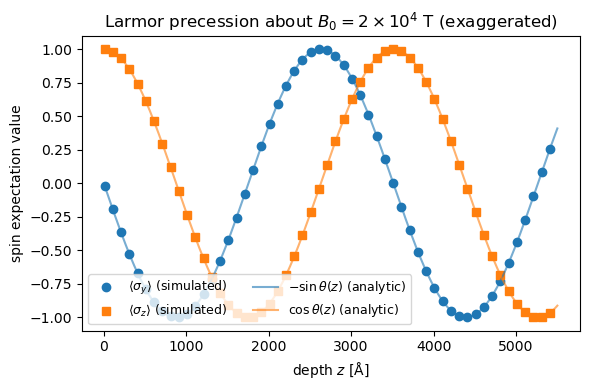

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(depths, spins[:, 1], "o", color="C0", markevery=10, label=r"$\langle\sigma_y\rangle$ (simulated)")
ax.plot(depths, spins[:, 2], "s", color="C1", markevery=10, label=r"$\langle\sigma_z\rangle$ (simulated)")
ax.plot(depths, expected[:, 1], "-", color="C0", alpha=0.6, label=r"$-\sin\theta(z)$ (analytic)")
ax.plot(depths, expected[:, 2], "-", color="C1", alpha=0.6, label=r"$\cos\theta(z)$ (analytic)")
ax.set_xlabel(r"depth $z$ [Å]")
ax.set_ylabel("spin expectation value")
ax.set_title(r"Larmor precession about $B_0 = 2\times 10^4$ T (exaggerated)")
ax.legend(loc="lower left", fontsize=9, ncol=2)
fig.tight_layout()

A spin initially *parallel* to the field, by contrast, should not precess at all: it is already an eigenstate of the Zeeman term.

In [4]:
# a plain (non-exit-plane-resolved) potential for this single-shot check
potential_final = abtem.PotentialArray(
    np.zeros((n_slices, gpts, gpts)), slice_thickness=dz, extent=(extent, extent)
)

spinor_parallel = abtem.PlaneWave(energy=energy, gpts=gpts, extent=extent).build(
    lazy=False
).to_spinor((1, 1))  # spin along +x, parallel to B

out_parallel = pauli_multislice(spinor_parallel, potential_final, vector_potential=A, magnetic_field=B)
s_parallel = spin_expectation(np.asarray(out_parallel.array))
print(f"<sigma_x, sigma_y, sigma_z> for spin parallel to B: {s_parallel}")
print(f"deviation from the stationary state (1, 0, 0): {np.abs(s_parallel - np.array([1, 0, 0])).max():.2e}")

<sigma_x, sigma_y, sigma_z> for spin parallel to B: [1. 0. 0.]
deviation from the stationary state (1, 0, 0): 1.78e-15


## Worked example: orbital phase from a vortex beam, via `average_field`

The orbital-coupling term can be isolated with a vortex probe (carrying orbital angular momentum $l$) passing through a uniform field aligned with the beam, $B_0 \hat z$. This is exactly the situation `average_field` is designed for — the field is axial, so (per the note above) the non-periodic vector potential it generates stays bounded regardless of propagation distance. Because the orbital and spin couplings share the same physical origin (they enter the Pauli equation with a relative factor of two — the electron's orbital-to-spin $g$-factor), the accumulated orbital phase is $\varphi(z) = -\dfrac{e B_0 l}{2\hbar k}\, z$, exactly half the Larmor rate above per unit of orbital angular momentum. We build a vortex probe with *ab*TEM's built-in `Vortex` aperture and propagate it with `average_field` set and unset, reading off the relative phase from the overlap of the two exit waves — since there is no periodic field here, `magnetic_field` is omitted entirely (only the periodic Zeeman term it would provide is skipped; `average_field`'s own Zeeman contribution still applies).


In [5]:
from abtem.transfer import Vortex

gpts_v, extent_v = 128, 40.0
dz_v, n_slices_v = 1.0, 10
B0_v = 2.0  # T, comparable to the saturation field of a transition-metal ferromagnet
l = 1

potential_v = abtem.PotentialArray(
    np.zeros((n_slices_v, gpts_v, gpts_v)), slice_thickness=dz_v,
    extent=(extent_v, extent_v),
)
zeros_v = np.zeros((n_slices_v, 3, gpts_v, gpts_v))
A_zero = VectorPotentialArray(zeros_v.copy(), slice_thickness=dz_v, extent=(extent_v, extent_v))

probe = abtem.Probe(
    aperture=Vortex(quantum_number=l, semiangle_cutoff=20.0),
    energy=energy,
    extent=extent_v,
    gpts=gpts_v,
)
vortex_spinor = probe.build(lazy=False).to_spinor((1, 0))

out_field = pauli_multislice(
    vortex_spinor.copy(), potential_v, vector_potential=A_zero,
    average_field=(0.0, 0.0, B0_v),
)
out_zero = pauli_multislice(
    vortex_spinor.copy(), potential_v, vector_potential=A_zero,
)

overlap = np.vdot(np.asarray(out_zero.array[0]), np.asarray(out_field.array[0]))
phase = np.angle(overlap)

wavelength_v = energy2wavelength(energy)
expected_phase = -e_over_hbar * wavelength_v / (2 * np.pi) * B0_v * l / 2 * (n_slices_v * dz_v)

print(f"simulated phase (orbital + on-axis Zeeman):  {phase:.6f} rad")
print(f"analytic orbital-only phase:                 {expected_phase:.6f} rad")

simulated phase (orbital + on-axis Zeeman):  -0.000002 rad
analytic orbital-only phase:                 -0.000001 rad


The simulated phase does not equal the analytic orbital-only phase above: with `average_field` supplying both the orbital coupling *and* its accompanying spin Zeeman rotation for the spin-up channel, the measured phase is the sum of the two, each of the same order of magnitude (the Zeeman contribution is exactly the $l$-independent single-channel case of the precession example above). Isolating the orbital part alone therefore requires cancelling that common Zeeman phase — the standard trick is to repeat the measurement for the opposite vorticity $-l$ and take the difference, which cancels the $l$-independent Zeeman phase and doubles the orbital one, $2\varphi(z)$.


In [6]:
def orbital_phase_via_average_field(l_value):
    probe_l = abtem.Probe(
        aperture=Vortex(quantum_number=l_value, semiangle_cutoff=20.0),
        energy=energy,
        extent=extent_v,
        gpts=gpts_v,
    )
    spinor_l = probe_l.build(lazy=False).to_spinor((1, 0))
    out_l = pauli_multislice(
        spinor_l.copy(), potential_v, vector_potential=A_zero,
        average_field=(0.0, 0.0, B0_v),
    )
    ref_l = pauli_multislice(spinor_l.copy(), potential_v, vector_potential=A_zero)
    return np.angle(np.vdot(np.asarray(ref_l.array[0]), np.asarray(out_l.array[0])))


phase_difference = orbital_phase_via_average_field(l) - orbital_phase_via_average_field(-l)
expected_difference = 2 * expected_phase

print(f"simulated 2 x orbital phase (+l minus -l): {phase_difference:.6f} rad")
print(f"analytic 2 x orbital phase:                {expected_difference:.6f} rad")
print(f"relative agreement: {abs(phase_difference - expected_difference) / abs(expected_difference):.2%}")

simulated 2 x orbital phase (+l minus -l): -0.000002 rad
analytic 2 x orbital phase:                -0.000002 rad
relative agreement: 1.88%


The $\pm l$ difference now agrees with the analytic orbital phase to a fraction of a percent, confirming that `average_field` reproduces the same orbital-coupling physics as an explicitly-supplied periodic vector potential, alongside the spin Zeeman term it also applies for an axial field.

## Performance and choosing collinear vs. non-collinear

The examples above use the default `algorithm=RealSpaceMultislice()`, an exact per-slice Taylor expansion of the full Pauli operator — simple and robust, but not the fastest option, and (as with any Taylor-series approach) it can fail to converge if a single slice's evolution operator is too large, as happens for an artificially strong field combined with thick slices. For anything beyond a small illustrative example, prefer `algorithm=FourierMultislice()`: a Strang-symmetrized operator-splitting scheme that solves the same paraxial equation roughly 5-15x faster (with an even larger advantage when scanning many probe positions, since it also benefits from the same Fourier-space batching as ordinary multislice) and applies the Zeeman rotation as an exact closed-form per-pixel spin rotation rather than a series expansion — at the cost of a slice-thickness-dependent splitting error that, like the ordinary FFT multislice algorithm, vanishes as the slices are made thinner.

Finally, if your material's magnetization is genuinely *collinear* (no canting, no in-plane component), you do not need any of the spinor machinery introduced here: the simpler, cheaper collinear path — folding the $A_z$ magnetic phase directly into an effective electrostatic-like potential — already agrees with this full Pauli treatment to within numerical precision for that special case, and only reach for `to_spinor()` and `pauli_multislice` once your magnetization is truly non-collinear.
